In [1]:
# !pwd

In [2]:
# !conda env list

In [3]:
# !pip install mne

# 0 read and drop unused data
> Respiration, heart rate (ECG/HRV) and galvanic
skin response (GSR) were also recorded, but results from
this data will not be reported here.
>
> https://sccn.ucsd.edu/~arno/mypapers/brandmeyer2016_author.pdf

In [685]:
import mne
import matplotlib.pyplot as plt

# since i can't upload too many data to GitHub, so please change the path based on where your data is stored.
# data_path = "./data"
data_path = "../data_local"
subnum = "001"
input_fname = f"{data_path}/ds001787-1.1.1/sub-{subnum}/ses-01/eeg/sub-{subnum}_ses-01_task-meditation_eeg.bdf"

raw = mne.io.read_raw_bdf(input_fname, preload=True)

print("______\n", raw.info)
raw.info

Extracting EDF parameters from /Users/zhuodicai/Desktop/uw_projects/eeg_meditation_Juan/data_local/ds001787-1.1.1/sub-001/ses-01/eeg/sub-001_ses-01_task-meditation_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 696575  =      0.000 ...  2720.996 secs...
______
 <Info | 8 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 79 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 52.0 Hz
 meas_date: 2014-04-04 19:40:17 UTC
 nchan: 80
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>


<Info | 8 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 79 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 52.0 Hz
 meas_date: 2014-04-04 19:40:17 UTC
 nchan: 80
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>

In [686]:
type(raw)

mne.io.edf.edf.RawEDF

In [687]:
print("Channel count:",len(raw.info.ch_names))
print("Channel names:",raw.info.ch_names)
print("Bad channels:", raw.info['bads'])

Channel count: 80
Channel names: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B14', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B31', 'B32', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Bad channels: []


<b>we only need EEG channels so drop others</b>

In [688]:
raw.drop_channels(["EXG1", "EXG2", "EXG3", "EXG4", "EXG5", "EXG6", "EXG7", "EXG8", "GSR1", "GSR2", "Erg1", "Erg2", "Resp", "Plet", "Temp", "Status"])

<RawEDF | sub-001_ses-01_task-meditation_eeg.bdf, 64 x 696576 (2721.0 s), ~340.2 MiB, data loaded>

In [689]:
raw['A1']

(array([[-0.00404095, -0.00404088, -0.00404938, ...,  0.0011112 ,
          0.00111292,  0.00111589]]),
 array([0.00000000e+00, 3.90625000e-03, 7.81250000e-03, ...,
        2.72098828e+03, 2.72099219e+03, 2.72099609e+03]))

In [690]:
# !pip install --upgrade jupyter
# !pip install --upgrade ipython

In [691]:
data, times = raw.get_data(return_times=True)
print(data.shape)
print(times.shape)

(64, 696576)
(696576,)


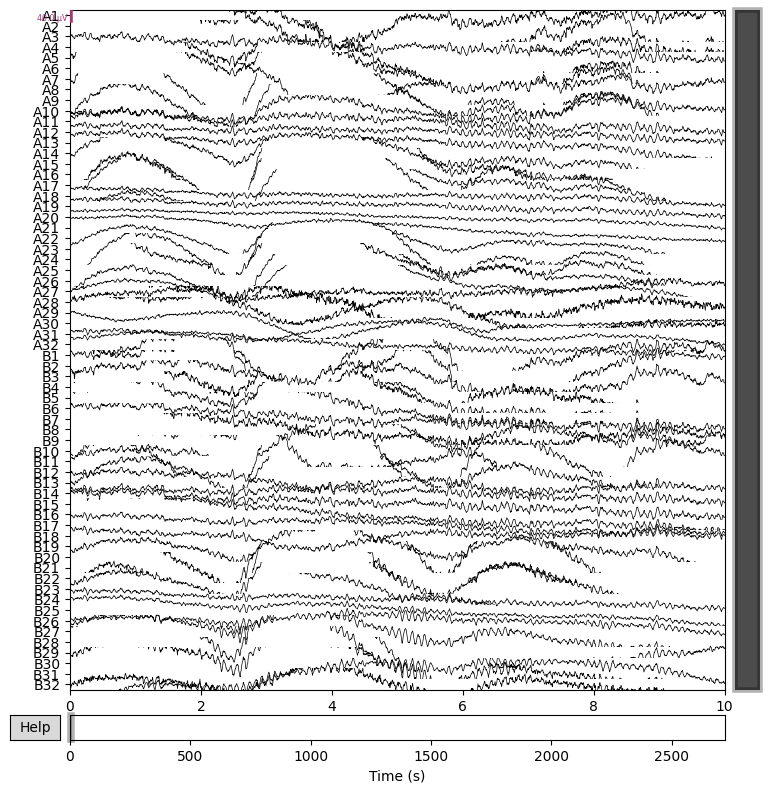

Figure(800x800)


In [692]:
print(raw.plot(n_channels=64))

# 1 apply standard montage (64-channels)
> We collected data using a <b>64 channels Biosemi system</b> and
a Biosemi 10-20 head cap montage at 2048 Hz sampling
rate. All electrodes were kept within an offset of 15 using the
Biosemi ActiView data acquisition system for measuring
impedance. 
>
> https://sccn.ucsd.edu/~arno/mypapers/brandmeyer2016_author.pdf

<b>standard montage built-in types</b>

https://mne.tools/0.21/generated/mne.channels.make_standard_montage.html

<b>check montage's naming convention and edit our channels names</b>

In [693]:
import mne
# biosemi64
# GSN-HydroCel-64_1.0

print("\n⬇️16——————\n")

montage = mne.channels.make_standard_montage('biosemi16')
# check its naming convention
print("🔵biosemi16:",len(montage.ch_names), montage.ch_names)

print("\n⬇️32——————\n")

montage = mne.channels.make_standard_montage('biosemi32')
# check its naming convention
print("🔵biosemi32:", len(montage.ch_names), montage.ch_names)

montage = mne.channels.make_standard_montage('GSN-HydroCel-32')
# check its naming convention
print("🔵GSN-HydroCel-32:", len(montage.ch_names), montage.ch_names)

print("\n⬇️64——————\n")

montage = mne.channels.make_standard_montage('biosemi64')
# check its naming convention
print("🔵biosemi64:",len(montage.ch_names), montage.ch_names)

montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
# check its naming convention
print("🔵GSN-HydroCel-64_1.0:", len(montage.ch_names), montage.ch_names)


⬇️16——————

🔵biosemi16: 16 ['Fp1', 'Fp2', 'F4', 'Fz', 'F3', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P4', 'Pz', 'P3', 'O1', 'Oz', 'O2']

⬇️32——————

🔵biosemi32: 32 ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz']
🔵GSN-HydroCel-32: 33 ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'Cz']

⬇️64——————

🔵biosemi64: 64 ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', '

## 1.1 GSN-HydroCel-64_1.0 (not this one, just test)
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64']

In [694]:
# channel_mapping = {}
# for i in range(32):
#     old_channel_name_A = 'A' + str(i + 1)
#     new_channel_name = 'E' + str(i + 1)
#     channel_mapping[old_channel_name_A] = new_channel_name
    
# for i in range(32):
#     old_channel_name_A = 'B' + str(i + 1)
#     new_channel_name = 'E' + str(i + 33)
#     channel_mapping[old_channel_name_A] = new_channel_name
    
# print(channel_mapping)

# # Rename the channels using the mapping dictionary
# raw.rename_channels(channel_mapping)

# # Print the new channel names
# print(raw.ch_names)

In [695]:
# ten_twenty_montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
# raw.set_montage(ten_twenty_montage)

In [696]:
# spectrum = raw.compute_psd()
# spectrum.plot(average=True, picks="data", exclude="bads")

In [697]:
# spectrum

## 1.2 biosemi64
['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']

In [698]:
# New channels names
new_channel_names = ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 
                     'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 
                     'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 
                     'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']

# mapping
channel_mapping = {}
for i in range(32):
    old_channel_name_A = 'A' + str(i + 1)
    new_channel_name_A = new_channel_names[i]
    channel_mapping[old_channel_name_A] = new_channel_name_A

for i in range(32):
    old_channel_name_B = 'B' + str(i + 1)
    new_channel_name_B = new_channel_names[i + 32]
    channel_mapping[old_channel_name_B] = new_channel_name_B


print(channel_mapping)

# Rename channels
raw.rename_channels(channel_mapping)

print(raw.ch_names)


{'A1': 'Fp1', 'A2': 'AF7', 'A3': 'AF3', 'A4': 'F1', 'A5': 'F3', 'A6': 'F5', 'A7': 'F7', 'A8': 'FT7', 'A9': 'FC5', 'A10': 'FC3', 'A11': 'FC1', 'A12': 'C1', 'A13': 'C3', 'A14': 'C5', 'A15': 'T7', 'A16': 'TP7', 'A17': 'CP5', 'A18': 'CP3', 'A19': 'CP1', 'A20': 'P1', 'A21': 'P3', 'A22': 'P5', 'A23': 'P7', 'A24': 'P9', 'A25': 'PO7', 'A26': 'PO3', 'A27': 'O1', 'A28': 'Iz', 'A29': 'Oz', 'A30': 'POz', 'A31': 'Pz', 'A32': 'CPz', 'B1': 'Fpz', 'B2': 'Fp2', 'B3': 'AF8', 'B4': 'AF4', 'B5': 'AFz', 'B6': 'Fz', 'B7': 'F2', 'B8': 'F4', 'B9': 'F6', 'B10': 'F8', 'B11': 'FT8', 'B12': 'FC6', 'B13': 'FC4', 'B14': 'FC2', 'B15': 'FCz', 'B16': 'Cz', 'B17': 'C2', 'B18': 'C4', 'B19': 'C6', 'B20': 'T8', 'B21': 'TP8', 'B22': 'CP6', 'B23': 'CP4', 'B24': 'CP2', 'B25': 'P2', 'B26': 'P4', 'B27': 'P6', 'B28': 'P8', 'B29': 'P10', 'B30': 'PO8', 'B31': 'PO4', 'B32': 'O2'}
['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9

In [699]:
ten_twenty_montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(ten_twenty_montage)

<RawEDF | sub-001_ses-01_task-meditation_eeg.bdf, 64 x 696576 (2721.0 s), ~340.2 MiB, data loaded>

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/publicplayground/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


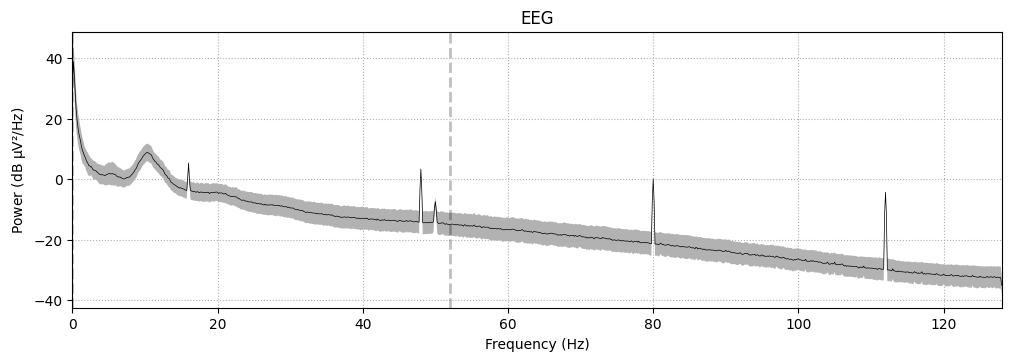

In [700]:
spectrum = raw.compute_psd()
spectrum.plot(average=True, picks="data", exclude="bads")

In [701]:
spectrum

Data type,Power Spectrum
Units,eeg: V²/Hz
Data source,Raw
Dims,"channel, freq"
Estimation method,welch
Number of channels,64
Number of frequency bins,1025
Frequency range,0.00 – 128.00 Hz


# 2 apply filter
> The raw EEG data was average referenced and downsampled from 2048 Hz to 256 Hz. A <b>high-pass filter at 2 Hz
</b>using a <b>infinite impulse response filter (IIR; transition
bandwidth of 0.7 Hz and order of 6)</b> was applied, and the
data was then average referenced again. 
>
> https://sccn.ucsd.edu/~arno/mypapers/brandmeyer2016_author.pdf

In [702]:
print(dir(raw.filter))
print("______")
print(dir(raw))

['__call__', '__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__func__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__self__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__']
______
['__class__', '__contains__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_annotations', '_cals', '_check_bad_segment', '_comp', '_cropped_samp', '_data', '_dtype', '_dtype_', '_extra_attributes', '_filenames', '_first_samps', '_first_time

In [703]:
# Set the filter parameters
order = 6
freq_cutoff = 2.0
transition_bandwidth = 0.7

# Design the high-pass IIR filter
raw.filter(l_freq=freq_cutoff, h_freq=None, method='iir', iir_params=dict(order=order, ftype='butter', output='sos', bw=transition_bandwidth))

raw.set_eeg_reference('average', projection=True)
raw.apply_proj()

# Apply the filter to the data
filtered_data = raw.get_data()

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 12 (effective, after forward-backward)
- Cutoff at 2.00 Hz: -6.02 dB

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


<MNELineFigure size 1000x350 with 0 Axes>

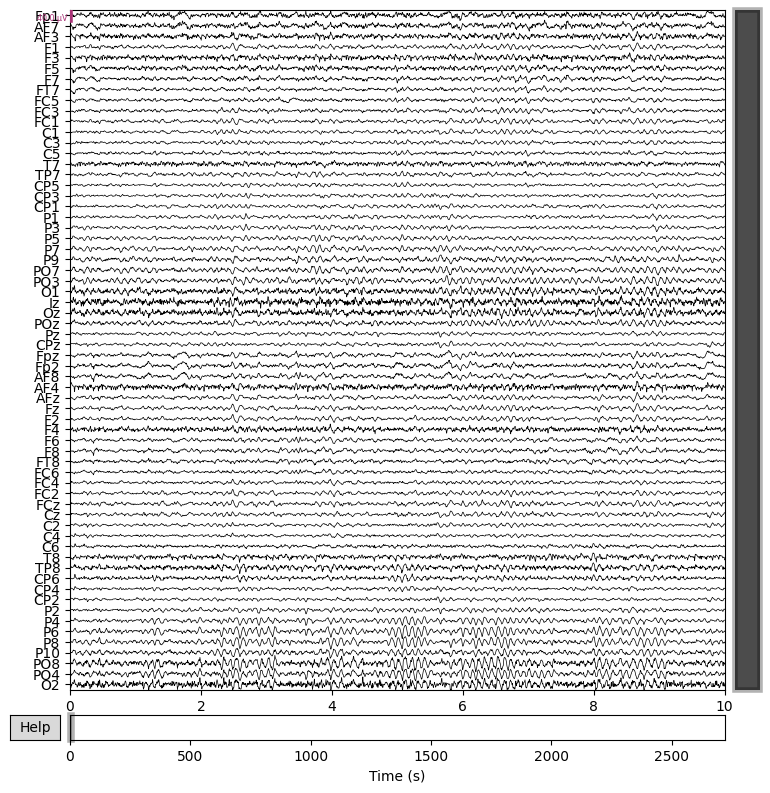

Figure(800x800)


In [704]:
plt.clf()
print(raw.plot(n_channels=64))

# 3 compute PSD (Power Spectral Density)
PSD is an effective method to differentiate between noise and features in a signal by making a spectral representation of the power distribution of its frequency components.

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).

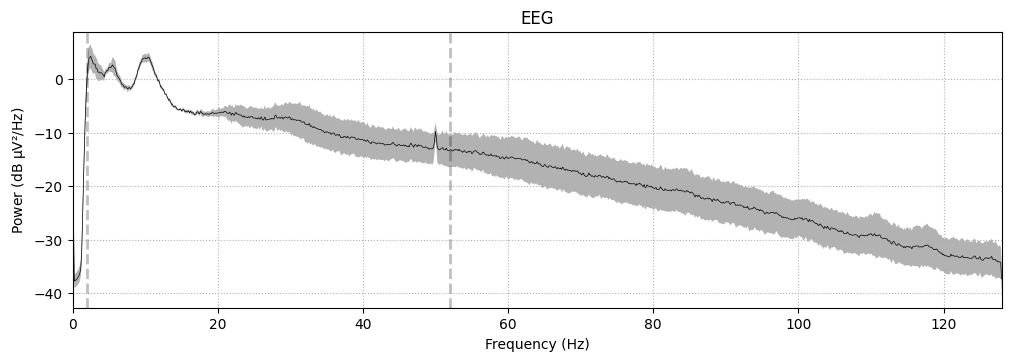

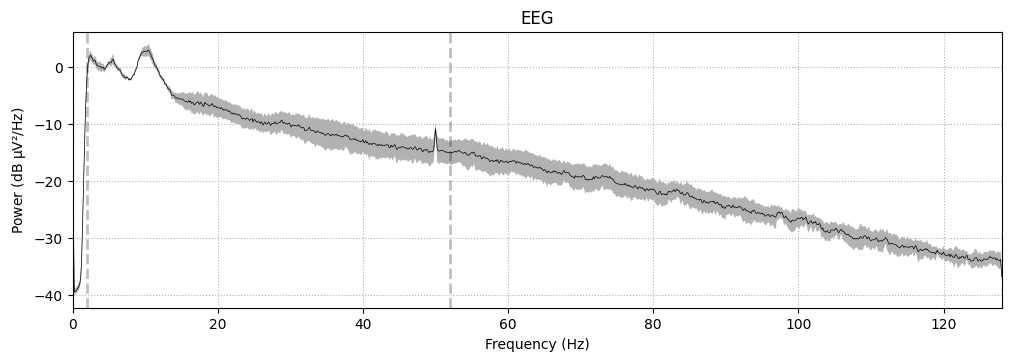

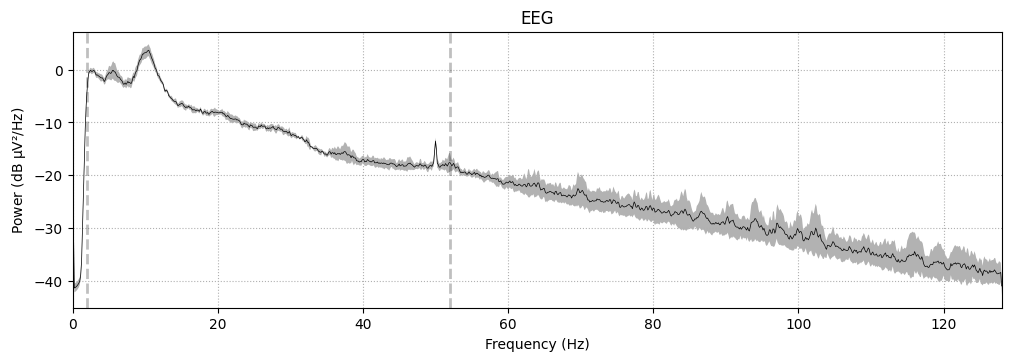

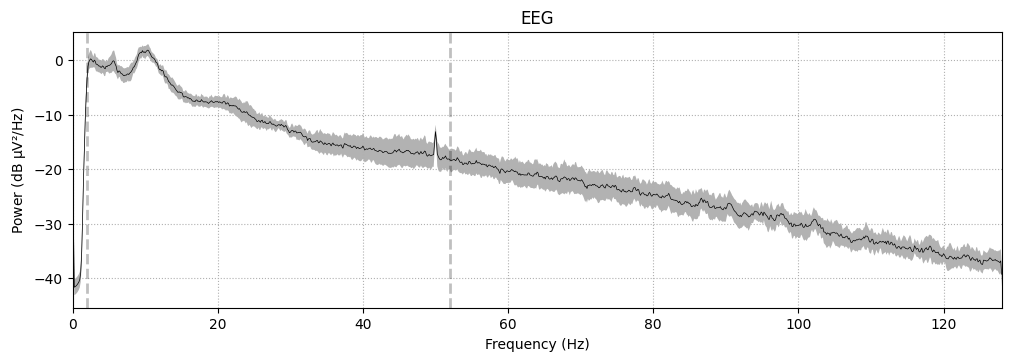

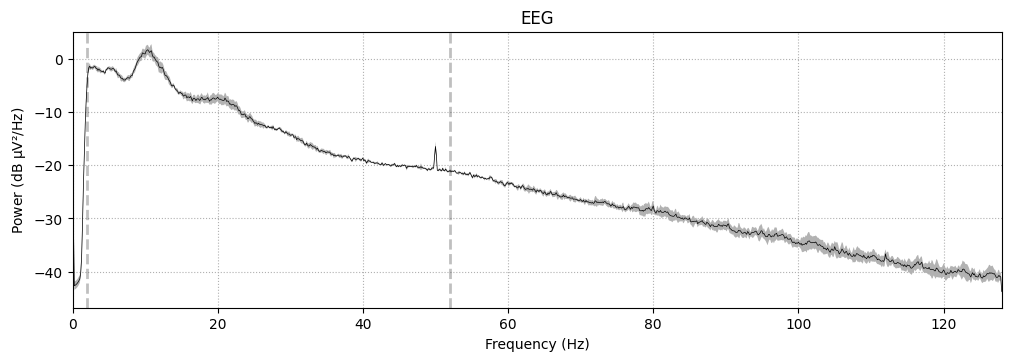

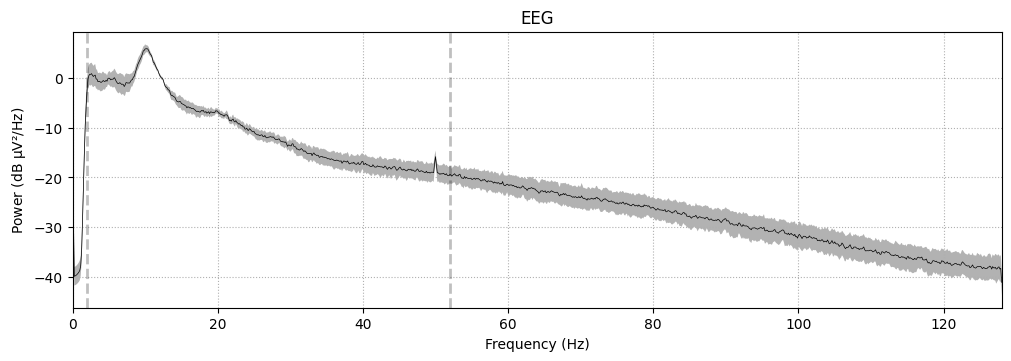

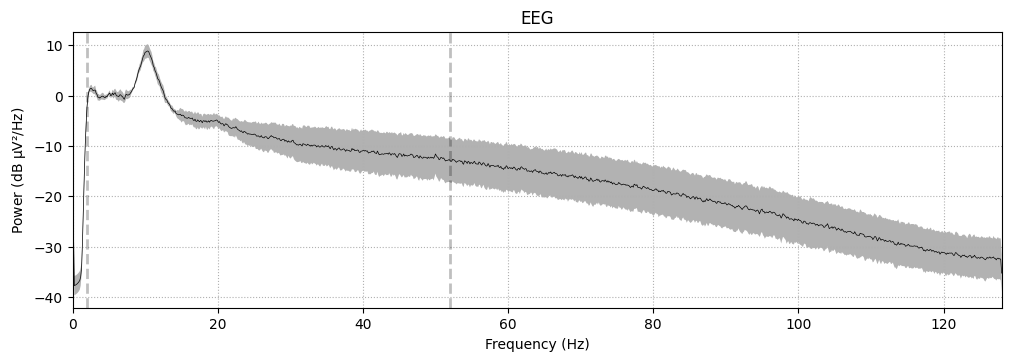

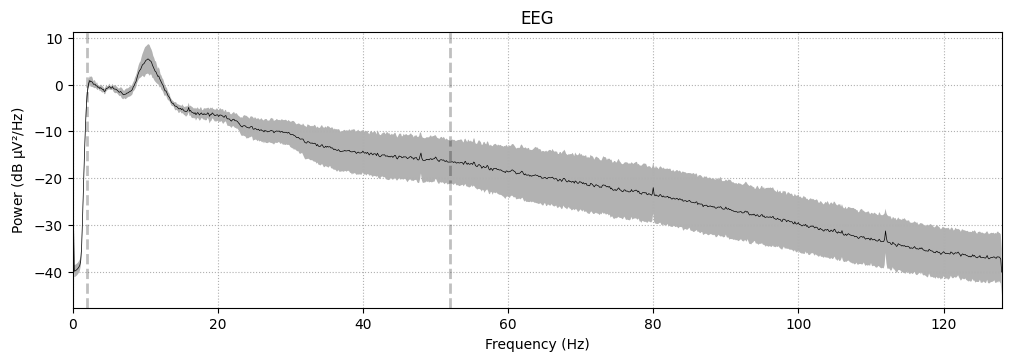

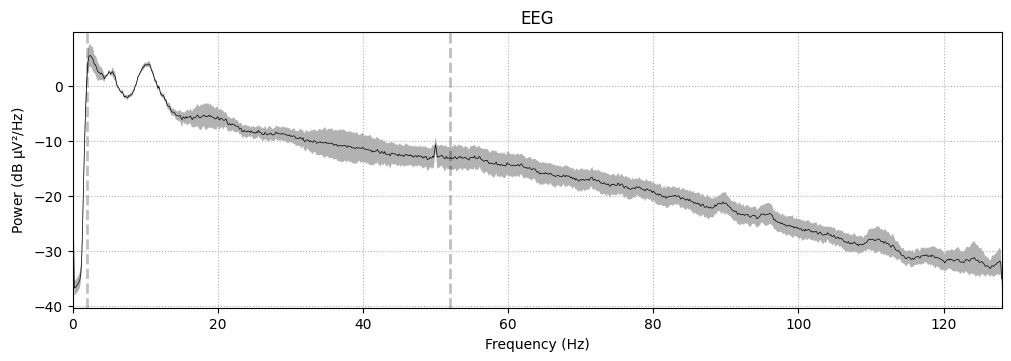

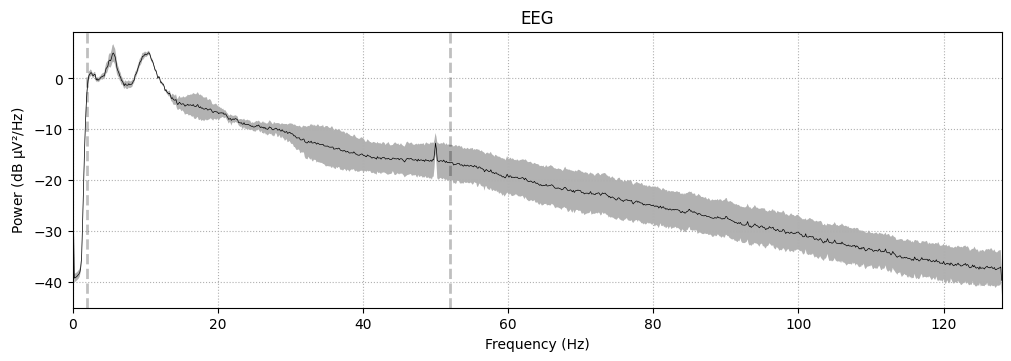

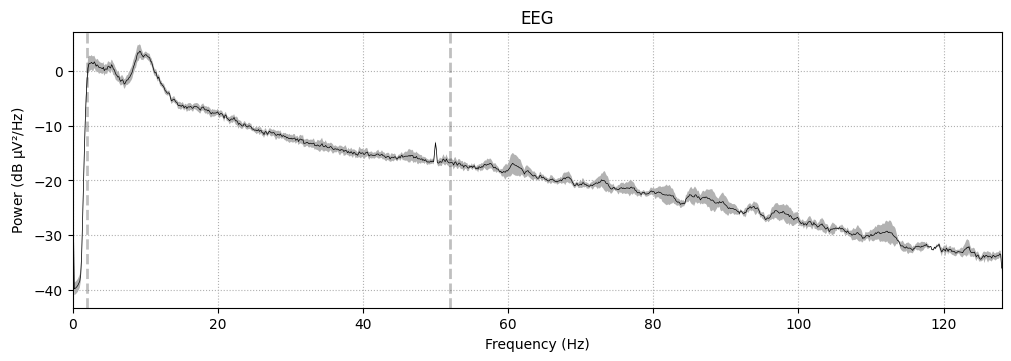

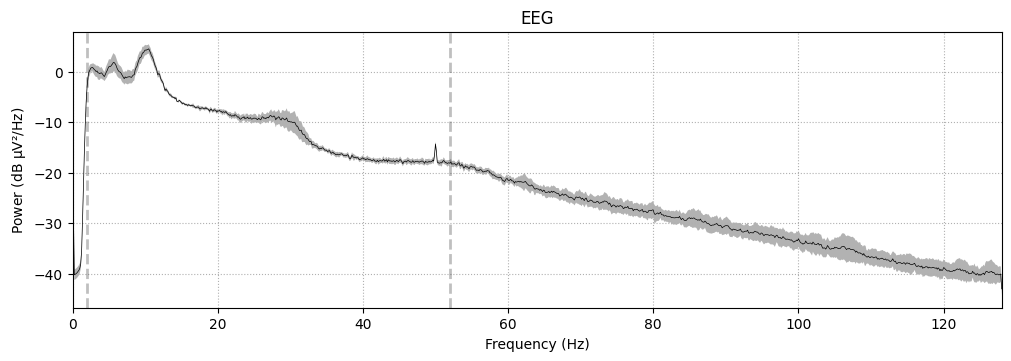

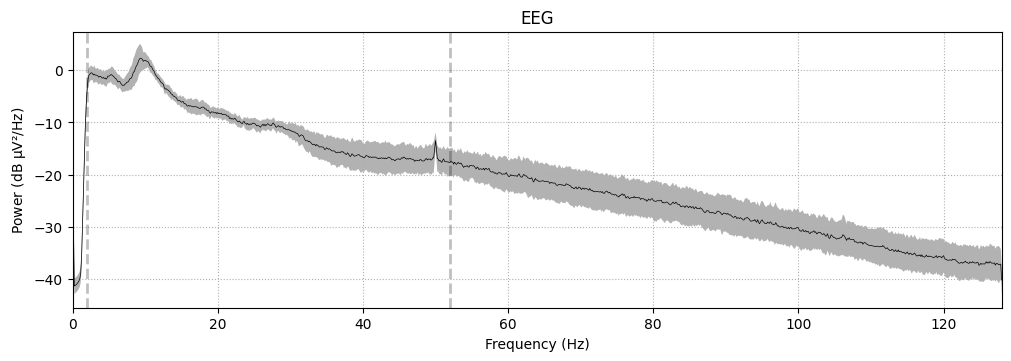

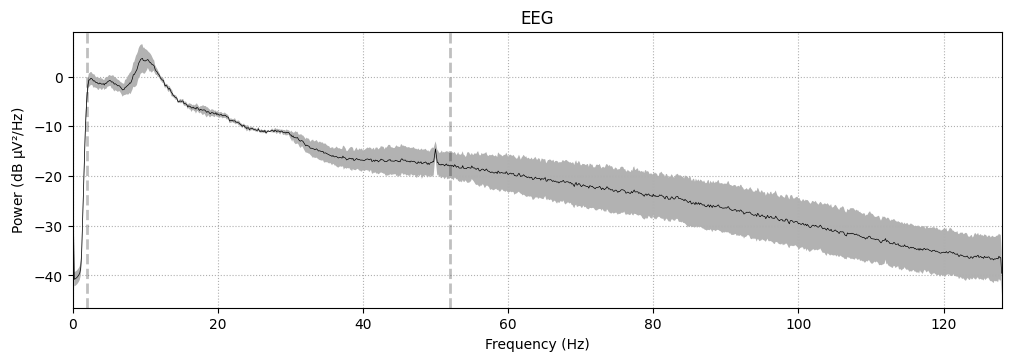

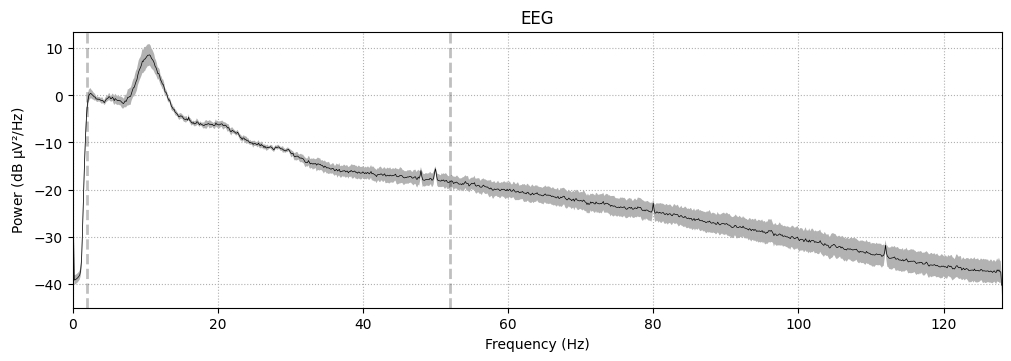

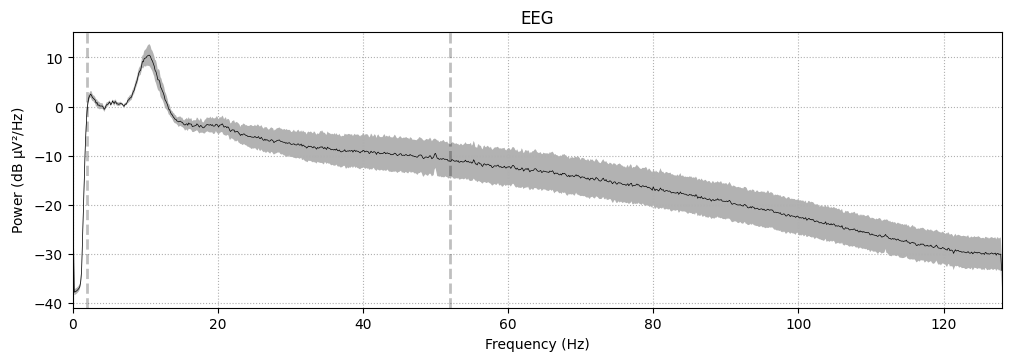

In [705]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Get the list of channel names
channel_names = raw.ch_names

# Iterate over each channel
for i in range(0,len(channel_names),4):

    # Select the channel and compute the power spectrum
    channel_data = raw.copy().pick([i,i+1,i+2,i+3])
    spectrum = channel_data.compute_psd()
    # Plot the power spectrum
    # spectrum.plot(average=False, picks="data", exclude="bads", show=False)
    spectrum.plot(average=True, picks="data", exclude="bads", show=False)

# Show the plot
plt.show()


# 4 ICA（Independent Component Analysis)

ICA（Independent Component Analysis) is one way to realize Blind Source Separation (BSS). In signal processing, independent component analysis (ICA) is a computational method for separating a multivariate signal into additive subcomponents.

Except for brain signal processing, music source separation is another use case. 🎵

## 4.1 n_components = 64 (it seems not good)

In [706]:
# raw1 = raw.copy()

In [707]:
# from mne.preprocessing import ICA
# ica = ICA(n_components=64, max_iter="auto", random_state=97)
# ica.fit(raw1)
# ica.apply(raw1)

In [708]:
# raw1.load_data()
# plt.clf()
# ica.plot_sources(raw1, picks=range(16))

# plt.clf()
# ica.plot_sources(raw1, picks=range(16, 32))

# plt.clf()
# ica.plot_sources(raw1, picks=range(32, 48))

# plt.clf()
# ica.plot_sources(raw1, picks=range(48, 63))

# # ica.plot_sources(raw1, picks=range(48,64))
# # ica.plot_sources(raw1, picks=range(64)) # can't scroll so print individually

In [709]:
# plt.clf()

In [710]:
# ica.plot_components()

In [711]:
# spectrum = raw1.compute_psd()
# spectrum.plot(average=True, picks="data", exclude="bads")

## 4.2 n_components = 63

In [712]:
raw2 = raw.copy()

In [713]:
from mne.preprocessing import ICA
ica = ICA(n_components=63, max_iter="auto", random_state=97)
ica.fit(raw2)
ica.apply(raw2)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
    Applying projection operator with 1 vector (pre-whitener computation)
    Applying projection operator with 1 vector (pre-whitener application)
Selecting by number: 63 components
    Applying projection operator with 1 vector (pre-whitener application)
Fitting ICA took 18.0s.
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (63 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components


<RawEDF | sub-001_ses-01_task-meditation_eeg.bdf, 64 x 696576 (2721.0 s), ~340.2 MiB, data loaded>

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=16, n_times=696576
    Range : 0 ... 696575 =      0.000 ...  2720.996 secs
Ready.


<Figure size 640x480 with 0 Axes>

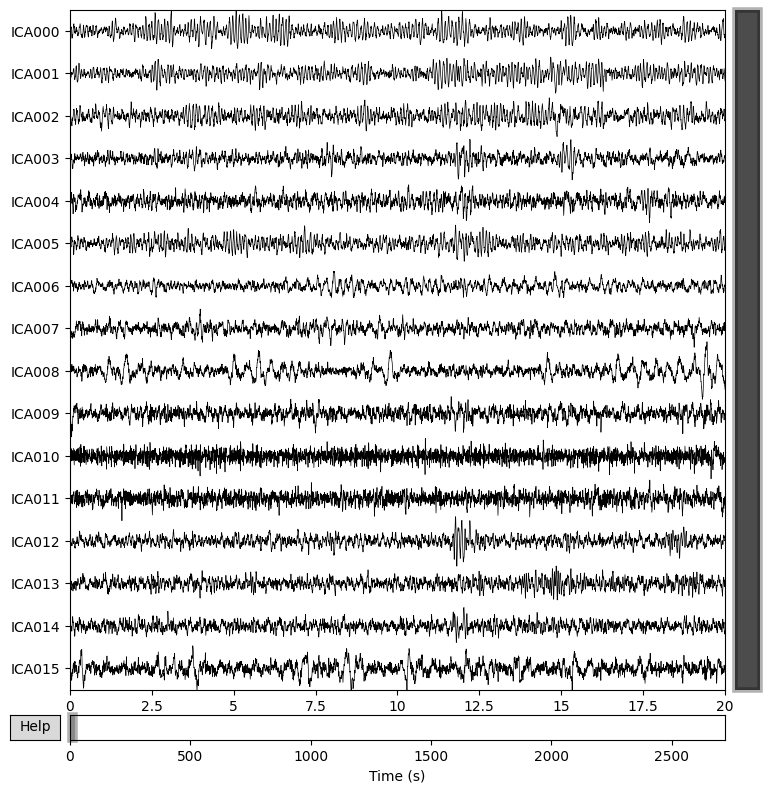

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=16, n_times=696576
    Range : 0 ... 696575 =      0.000 ...  2720.996 secs
Ready.


<Figure size 640x480 with 0 Axes>

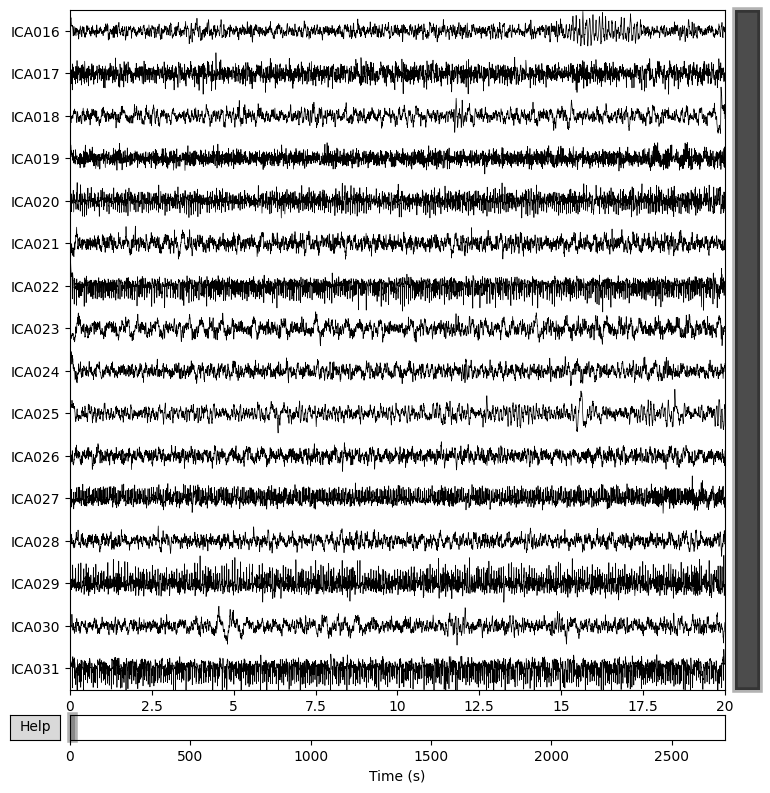

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=16, n_times=696576
    Range : 0 ... 696575 =      0.000 ...  2720.996 secs
Ready.


<Figure size 640x480 with 0 Axes>

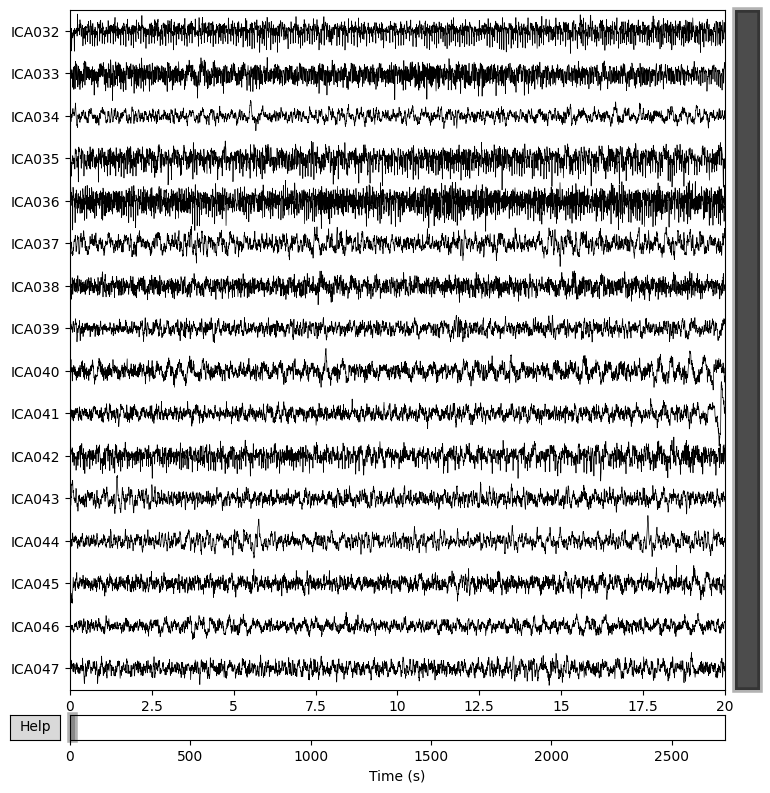

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=15, n_times=696576
    Range : 0 ... 696575 =      0.000 ...  2720.996 secs
Ready.


<Figure size 640x480 with 0 Axes>

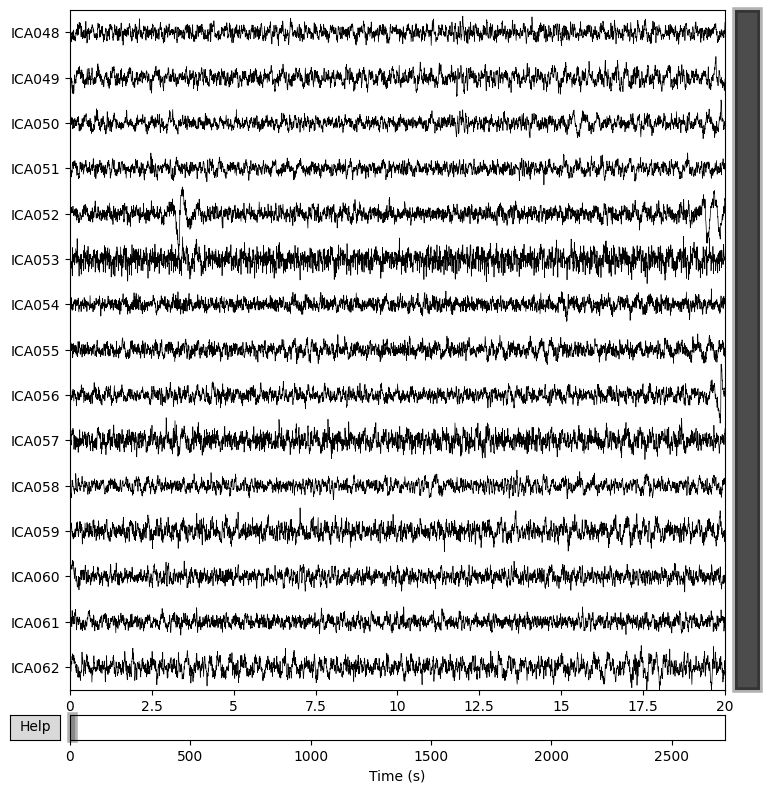

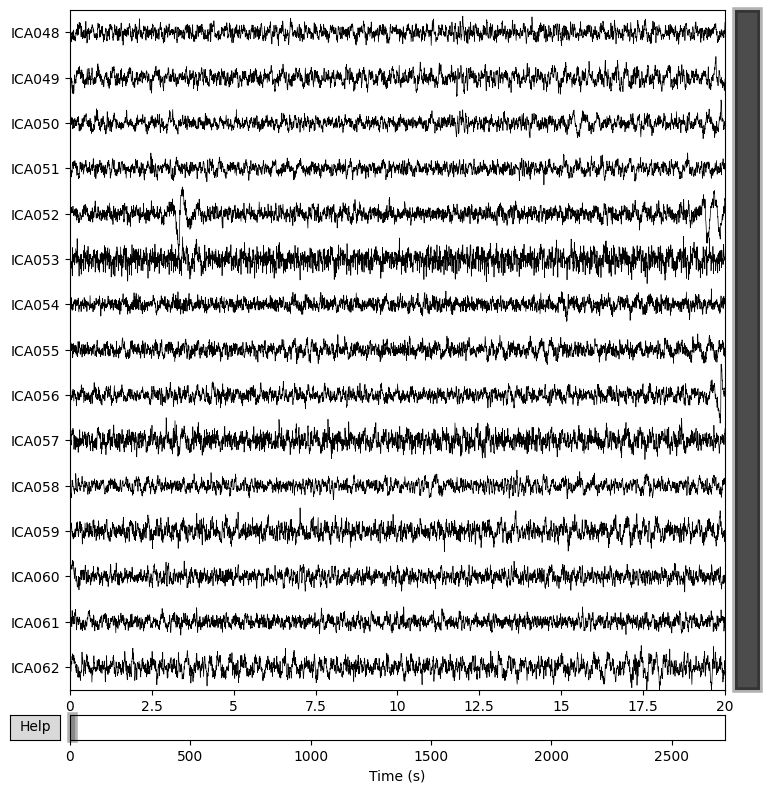

In [714]:
raw2.load_data()
plt.clf()
ica.plot_sources(raw2, picks=range(16))

plt.clf()
ica.plot_sources(raw2, picks=range(16, 32))

plt.clf()
ica.plot_sources(raw2, picks=range(32, 48))

plt.clf()
ica.plot_sources(raw2, picks=range(48, 63))

# ica.plot_sources(raw2, picks=range(48,64))
# ica.plot_sources(raw2, picks=range(64)) # can't scroll so print individually

<Figure size 640x480 with 0 Axes>

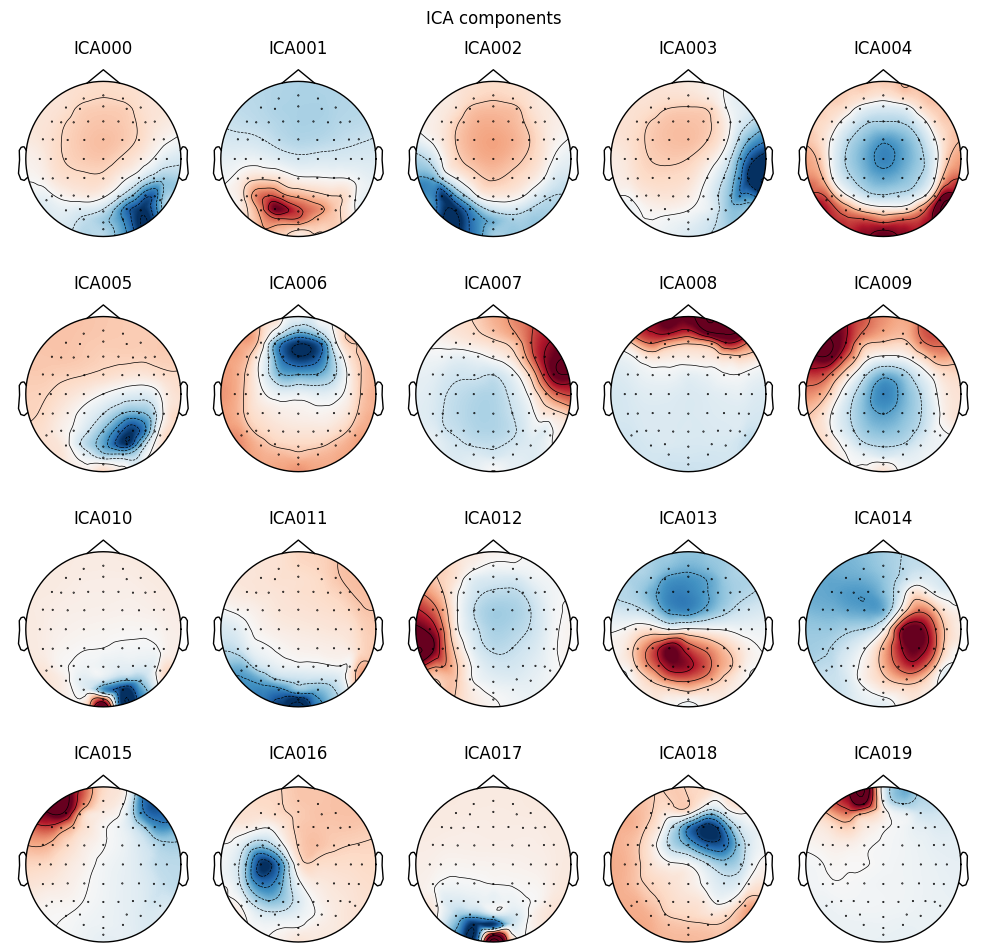

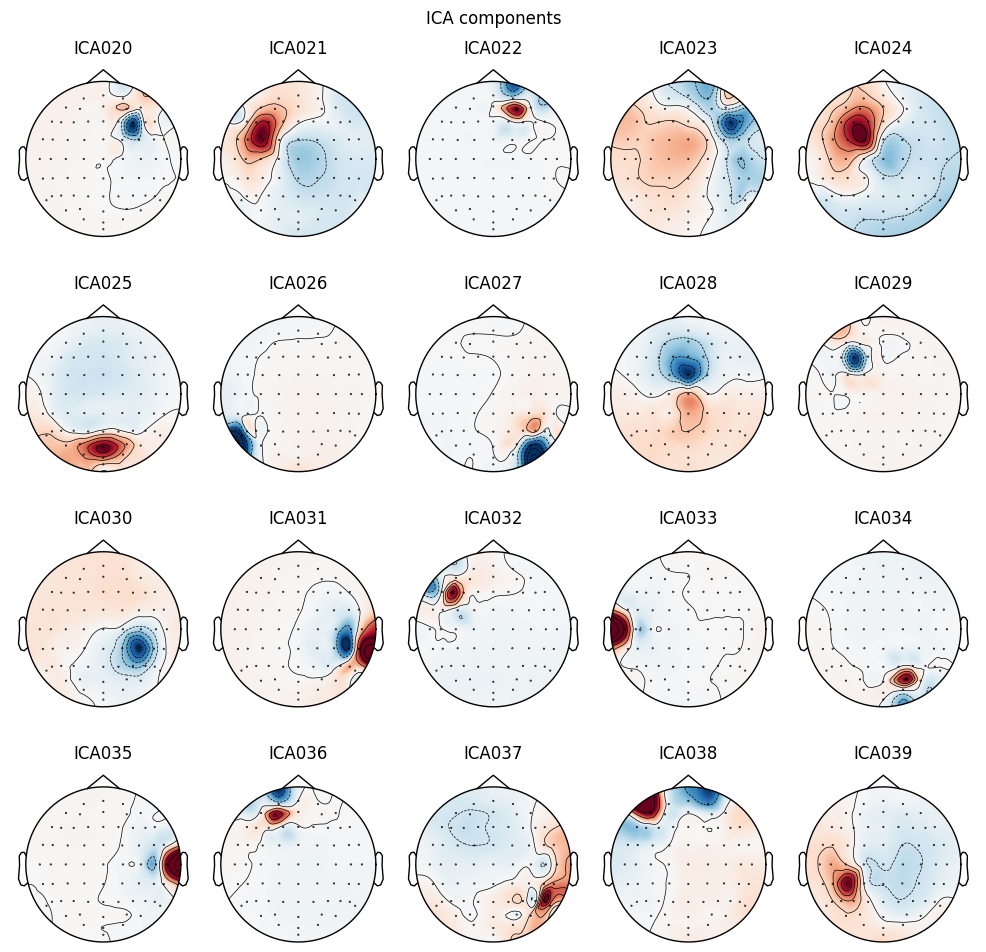

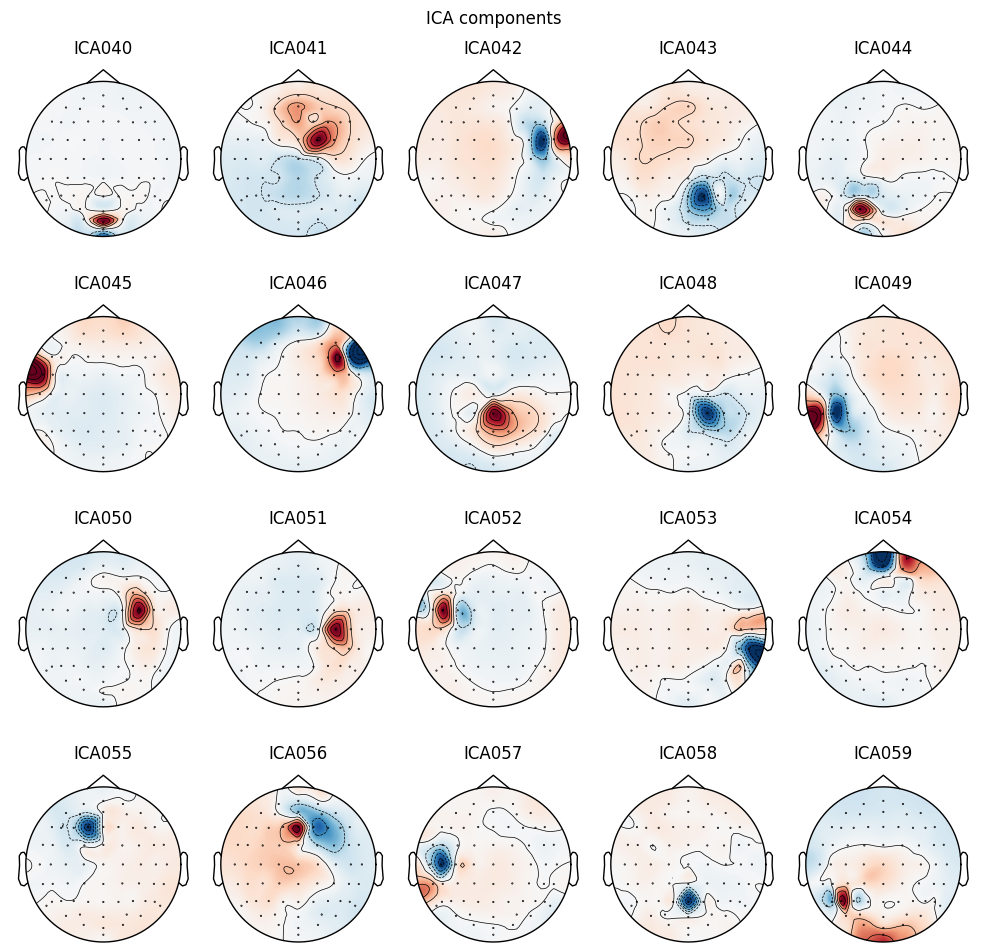

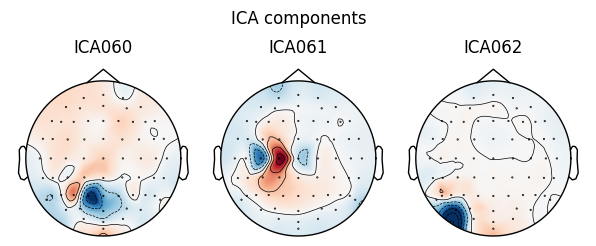

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 585x260.5 with 3 Axes>]

In [715]:
plt.clf()
ica.plot_components()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/publicplayground/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


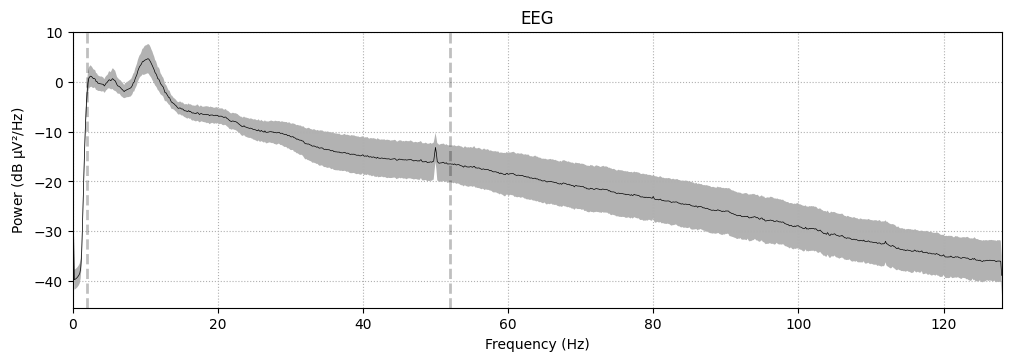

In [716]:
spectrum = raw2.compute_psd()
plt.clf()
spectrum.plot(average=True, picks="data", exclude="bads")

In [717]:
# print(spectrum)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/publicplayground/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/var/folders/ws/b2m77y3j28j4rp5lp7ws60hr0000gn/T/ipykernel_92884/840249937.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

<MNELineFigure size 1000x350 with 0 Axes>

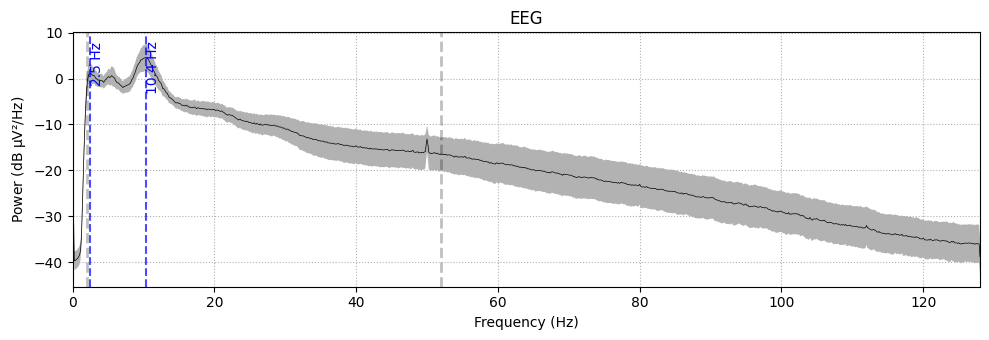

In [718]:
import numpy as np
spectrum = raw2.compute_psd()
plt.clf()

# draw the above PSD fig first
fig = spectrum.plot(average=True, picks="data", exclude="bads")

# get PSD data to find the power's peaks
freqs = spectrum.freqs
psds = spectrum.get_data(return_freqs=False)
avg_psd = psds.mean(axis=0)
db_avg_psd = 10 * np.log10(avg_psd)

# find peaks
from scipy.signal import find_peaks
peaks, properties = find_peaks(db_avg_psd, prominence=3)

# sort peaks by power
peak_powers = db_avg_psd[peaks]
peak_freqs = freqs[peaks]
sorted_indices = np.argsort(-peak_powers)
top_peaks = sorted_indices[:5]  # maximum top5 peaks

# mark the peaks on fig
for idx in top_peaks:
    freq = peak_freqs[idx]
    power = peak_powers[idx]
    plt.axvline(x=freq, color='blue', linestyle='--', alpha=0.7)
    plt.text(freq, plt.ylim()[1]-2, f"{freq:.1f} Hz", 
             rotation=90, color='blue', verticalalignment='top')

plt.tight_layout()
plt.savefig(f'ds001787-1.1.1_sub-{subnum}_ses-01.png')
plt.show()